## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.base import clone
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                     RepeatedStratifiedKFold, cross_validate)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, recall_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

SEED = 42

SEED = 42

## 1. Import Dataset

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
atributos = iris.feature_names
nomes = list(iris.target_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Análise Dataset

In [3]:
df.info()
print()
print("Valores ausentes:", df.isnull().sum().sum())
print("Linhas duplicadas:", df.duplicated().sum())
print()
print(df["species"].value_counts())
df[atributos].describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Valores ausentes: 0
Linhas duplicadas: 1

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


**Análise.** Todos os atributos são numéricos (float64), não há valores ausentes e as três espécies têm 50 amostras cada, ou seja, as classes são balanceadas. Encontrada uma linha duplicada.

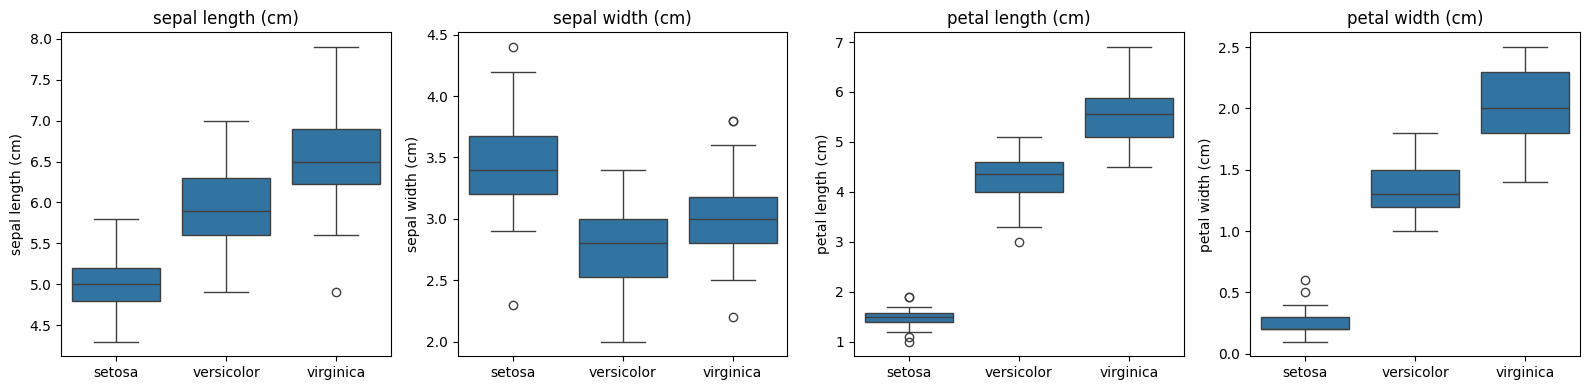

Outliers pelo critério do IQR (1,5 x IQR):
  sepal length (cm): 0
  sepal width (cm): 4
  petal length (cm): 0
  petal width (cm): 0


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, atributos):
    sns.boxplot(data=df, x="species", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

print("Outliers pelo critério do IQR (1,5 x IQR):")
for col in atributos:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    out = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(f"  {col}: {len(out)}")

**Análise do gráfico.** Apenas a largura da sépala apresenta valores fora do critério do IQR, quatro no total, três de setosa (4,4, 4,1 e 4,2) e um de versicolor (2,0). São medidas plausíveis para a espécie e não erros de registro, e, com 149 amostras, removê-las reduziria a base sem justificativa. Os pontos foram mantidos. O comprimento e a largura da pétala não têm outliers.

sepal length (cm)       sepal width (cm)       petal length (cm)  \
                        mean   std             mean   std              mean   
species                                                                       
setosa                  5.01  0.35             3.43  0.38              1.46   
versicolor              5.94  0.52             2.77  0.31              4.26   
virginica               6.59  0.64             2.97  0.32              5.55   

                 petal width (cm)        
             std             mean   std  
species                                  
setosa      0.17             0.25  0.11  
versicolor  0.47             1.33  0.20  
virginica   0.55             2.03  0.27

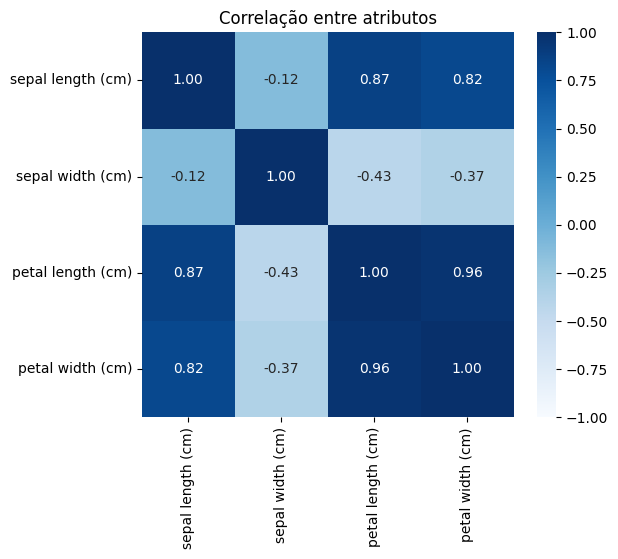

In [5]:
display(df.groupby("species")[atributos].agg(["mean", "std"]).round(2))

plt.figure(figsize=(6, 5))
sns.heatmap(df[atributos].corr(), annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlação entre atributos")
plt.show()

**Análise da correlação.** As médias por espécie mostram que as pétalas separam bem os grupos: o comprimento médio da pétala é de 1,46 cm na setosa, 4,26 na versicolor e 5,56 na virginica, e a largura vai de 0,25 a 1,33 e a 2,03. Os desvios dentro de cada espécie são pequenos perto dessas diferenças, exceto entre versicolor e virginica, onde as faixas se aproximam.

O comprimento e a largura da pétala têm correlação de 0,96, e ambos se correlacionam com o comprimento da sépala (0,87 e 0,82). A largura da sépala é a menos associada aos demais atributos, com correlação negativa de 0,36 com a largura da pétala. Correlação indica relação linear entre atributos e não causalidade, e aqui sinaliza que os atributos de pétala carregam informação parecida.

## 2.1 Tratamento Duplicadas

In [6]:
print("Linhas duplicadas encontradas:")
display(df[df.duplicated(keep=False)])

df = df.drop_duplicates().reset_index(drop=True)
print("\nFormato após remoção:", df.shape)
print(df["species"].value_counts())

Linhas duplicadas encontradas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
101,5.8,2.7,5.1,1.9,2,virginica
142,5.8,2.7,5.1,1.9,2,virginica



Formato após remoção: (149, 6)
species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64


**Análise.** As linhas 101 e 142 são idênticas (virginica, 5,8 / 2,7 / 5,1 / 1,9). Mantê-las daria peso dobrado a uma amostra e poderia colocar uma cópia no treino e outra no teste, o que vazaria informação para a avaliação. A duplicata foi removida, restando 149 amostras, 50 de setosa, 50 de versicolor e 49 de virginica.

## 3. Divisão em treino e teste

Divisão estratificada, com 80% para treino e 20% para teste. 

In [7]:
#O treino ficou com 119 amostras e o teste com 30, 10 de cada espécie. 

X = df[atributos]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(X_train.shape, X_test.shape)
print("Classes no teste:", y_test.value_counts().to_dict())

(119, 4) (30, 4)
Classes no teste: {1: 10, 2: 10, 0: 10}


## 4. Modelos sem GridSearchCV

Os quatro algoritmos são treinados com os hiperparâmetros padrão do scikit-learn. O SVM é colocado em um Pipeline com `StandardScaler`, pois depende da escala dos atributos, e o escalonador é ajustado somente com os dados de treino. As árvores e os ensembles não exigem padronização.

In [8]:
modelos_base = {
    "SVM": Pipeline([("scaler", StandardScaler()), ("clf", SVC(random_state=SEED))]),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=SEED),
    "Floresta Aleatória": RandomForestClassifier(random_state=SEED),
    "Boosting": GradientBoostingClassifier(random_state=SEED),
}

resultados, preds = [], {}

def registrar(nome, versao, modelo):
    pred_tr = modelo.predict(X_train)
    pred_te = modelo.predict(X_test)
    preds[(nome, versao)] = pred_te
    resultados.append({
        "Modelo": nome,
        "Versão": versao,
        "Acurácia treino": accuracy_score(y_train, pred_tr),
        "Acurácia teste": accuracy_score(y_test, pred_te),
        "Sensibilidade teste (macro)": recall_score(y_test, pred_te, average="macro"),
    })

for nome, m in modelos_base.items():
    m.fit(X_train, y_train)
    registrar(nome, "Sem GridSearch", m)

pd.DataFrame(resultados).round(4)

,Modelo,Versão,Acurácia treino,Acurácia teste,Sensibilidade teste (macro)
0,SVM,Sem GridSearch,0.9748,0.9667,0.9667
1,Árvore de Decisão,Sem GridSearch,1.0000,0.9333,0.9333
2,Floresta Aleatória,Sem GridSearch,1.0000,0.9333,0.9333
3,Boosting,Sem GridSearch,1.0000,0.9667,0.9667


**Análise SVM.** Com a configuração padrão, SVM e Boosting alcançaram 96,67% de acurácia e de sensibilidade no teste, e Árvore de Decisão e Floresta Aleatória 93,33%. A Árvore e a Floresta acertaram 100% do treino, enquanto o SVM acertou 97,48%.

## 5. Modelos com GridSearchCV

Grades testadas:
SVM: C, kernel (linear e rbf) e gamma.
Árvore de Decisão: profundidade máxima, mínimo de amostras para divisão e para folha, e critério (gini ou entropy).
Floresta Aleatória: número de árvores, profundidade máxima, mínimo de amostras para divisão e máximo de atributos por divisão.
Boosting: número de estimadores, taxa de aprendizado e profundidade das árvores.


In [9]:
grades = {
    "SVM": {"clf__C": [0.1, 1, 10, 100],
            "clf__kernel": ["linear", "rbf"],
            "clf__gamma": ["scale", 0.1, 1]},
    "Árvore de Decisão": {"max_depth": [2, 3, 4, 5, None],
                          "min_samples_split": [2, 5, 10],
                          "min_samples_leaf": [1, 2, 4],
                          "criterion": ["gini", "entropy"]},
    "Floresta Aleatória": {"n_estimators": [50, 100, 200],
                           "max_depth": [None, 3, 5],
                           "min_samples_split": [2, 5],
                           "max_features": ["sqrt", None]},
    "Boosting": {"n_estimators": [50, 100, 200],
                 "learning_rate": [0.01, 0.1, 0.5],
                 "max_depth": [1, 2, 3]},
}

cv_interno = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
melhores = {}

for nome, m in modelos_base.items():
    gs = GridSearchCV(clone(m), grades[nome], cv=cv_interno,
                      scoring="recall_macro", n_jobs=-1)
    gs.fit(X_train, y_train)
    melhores[nome] = gs
    registrar(nome, "Com GridSearch", gs.best_estimator_)
    print(nome)
    print(f"  Melhores parâmetros: {gs.best_params_}")
    print(f"  Sensibilidade média na validação cruzada do treino: {gs.best_score_:.4f}\n")

SVM
  Melhores parâmetros: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
  Sensibilidade média na validação cruzada do treino: 0.9714

Árvore de Decisão
  Melhores parâmetros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
  Sensibilidade média na validação cruzada do treino: 0.9381

Floresta Aleatória
  Melhores parâmetros: {'max_depth': 3, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 50}
  Sensibilidade média na validação cruzada do treino: 0.9536

Boosting
  Melhores parâmetros: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50}
  Sensibilidade média na validação cruzada do treino: 0.9464



**Análise.** A busca selecionou para o SVM o kernel linear com C igual a 0,1, uma regularização forte, coerente com a análise exploratória, que mostrou espécies quase separáveis por fronteiras lineares nos atributos de pétala. Para a Árvore escolheu profundidade máxima 3 com mínimo de 4 amostras por folha, para a Floresta árvores de profundidade 3 e para o Boosting árvores de profundidade 2 com taxa de aprendizado de 0,01.

## 6. Comparação no conjunto de teste


Acurácia teste                Sensibilidade teste (macro)  \
Versão             Com GridSearch Sem GridSearch              Com GridSearch   
Modelo                                                                         
Boosting                   0.9667         0.9667                      0.9667   
Floresta Aleatória         0.9667         0.9333                      0.9667   
SVM                        0.9333         0.9667                      0.9333   
Árvore de Decisão          0.9667         0.9333                      0.9667   

                                   
Versão             Sem GridSearch  
Modelo                             
Boosting                   0.9667  
Floresta Aleatória         0.9333  
SVM                        0.9667  
Árvore de Decisão          0.9333

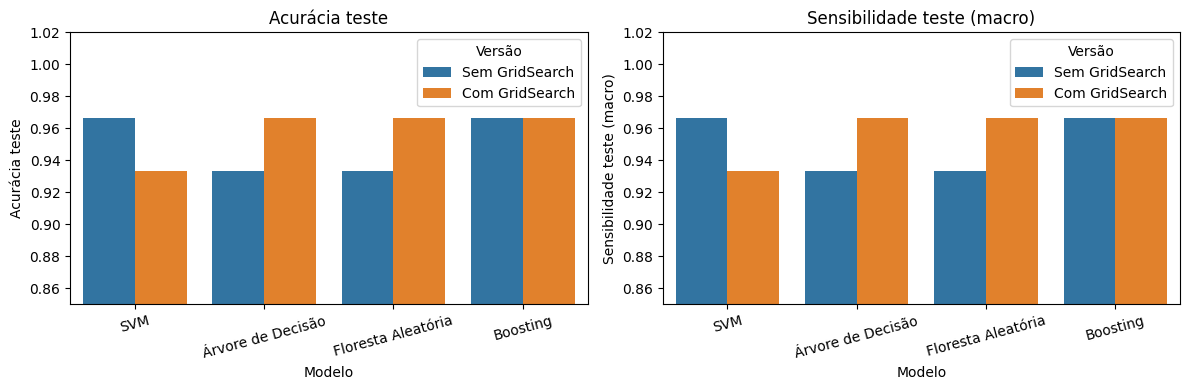

In [10]:
df_res = pd.DataFrame(resultados)

tabela = df_res.pivot(index="Modelo", columns="Versão",
                      values=["Acurácia teste", "Sensibilidade teste (macro)"]).round(4)
display(tabela)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metrica in zip(axes, ["Acurácia teste", "Sensibilidade teste (macro)"]):
    sns.barplot(data=df_res, x="Modelo", y=metrica, hue="Versão", ax=ax)
    ax.set_ylim(0.85, 1.02)
    ax.set_title(metrica)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

,Modelo,Versão,Sens. setosa,Sens. versicolor,Sens. virginica
0,SVM,Sem GridSearch,1.0,0.9,1.0
1,Árvore de Decisão,Sem GridSearch,1.0,0.9,0.9
2,Floresta Aleatória,Sem GridSearch,1.0,0.9,0.9
3,Boosting,Sem GridSearch,1.0,0.9,1.0
4,SVM,Com GridSearch,1.0,0.9,0.9
5,Árvore de Decisão,Com GridSearch,1.0,0.9,1.0
6,Floresta Aleatória,Com GridSearch,1.0,0.9,1.0
7,Boosting,Com GridSearch,1.0,0.9,1.0


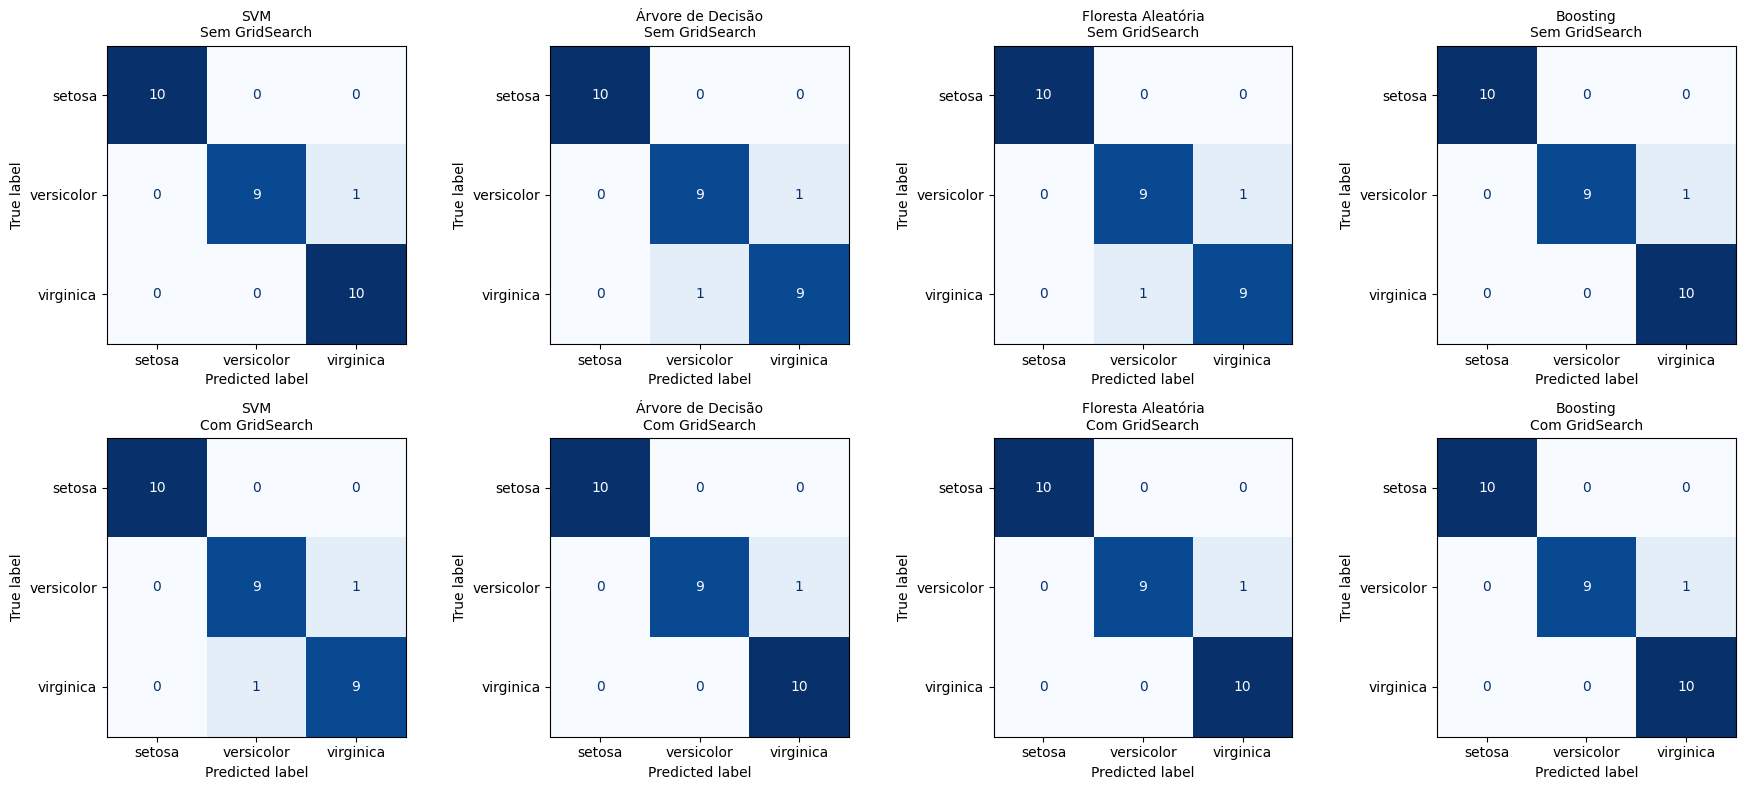

In [11]:
linhas = []
for (nome, versao), pred in preds.items():
    rec = recall_score(y_test, pred, average=None)
    linhas.append({"Modelo": nome, "Versão": versao,
                   **{f"Sens. {n}": r for n, r in zip(nomes, rec)}})
display(pd.DataFrame(linhas).round(4))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, ((nome, versao), pred) in zip(axes.ravel(), preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=nomes).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{nome}\n{versao}", fontsize=10)
plt.tight_layout()
plt.show()

**Análise.** No teste, Árvore de Decisão, Floresta Aleatória e Boosting com GridSearchCV alcançaram 96,67%, o mesmo resultado do SVM e do Boosting sem GridSearchCV. O SVM com GridSearchCV, a Árvore e a Floresta sem GridSearchCV ficaram em 93,33%. Cinco configurações empatam no topo, e a diferença para as demais é de uma única amostra, de modo que o teste, sozinho, não aponta um vencedor.

A setosa foi classificada com sensibilidade de 100% por todos os modelos. Todas as oito versões acertaram 9 das 10 versicolor, ou seja, erraram a mesma proporção nessa classe. A diferença entre os modelos está na virginica: SVM padrão, Boosting (com e sem busca), Árvore com busca e Floresta com busca acertaram todas, enquanto SVM com busca, Árvore padrão e Floresta padrão erraram uma. Os erros se concentram, portanto, entre versicolor e virginica, as espécies que se aproximam nos atributos.

## 9. Conclusão

No conjunto de teste, cinco configurações empataram com o melhor resultado, 96,67% de acurácia e de sensibilidade: SVM sem GridSearchCV, Boosting com e sem GridSearchCV, Árvore de Decisão com GridSearchCV e Floresta Aleatória com GridSearchCV. Todas erraram exatamente uma amostra, uma versicolor classificada como virginica.

Como critério de desempate, o modelo indicado é o SVM sem GridSearchCV, por alcançar o melhor resultado com a configuração padrão, sem exigir busca de hiperparâmetros, e por apresentar a menor diferença entre treino e teste (97,48% contra 96,67%). O Boosting também se destaca por manter 96,67% com e sem ajuste, o que indica estabilidade frente à escolha de hiperparâmetros.

O efeito do GridSearchCV variou entre os modelos. Melhorou a Árvore de Decisão e a Floresta Aleatória, de 93,33% para 96,67%, porque limitou a profundidade das árvores, que na configuração padrão acertavam 100% do treino e se ajustavam demais a ele. Foi neutro para o Boosting e piorou o SVM, de 96,67% para 93,33%.

A setosa é separada com sensibilidade de 100% por todos os modelos, e os erros ocorrem entre versicolor e virginica, que se aproximam nas medidas de pétala e de sépala, como mostrado na análise dataset.